# Exploração BeforeIT — Anexo 2 da Parte 4: grade de intensidade e participação no mercado de apostas

Esta parte analisa como os resultados mudam quando aumentamos separadamente a parcela da renda apostada e a proporção de trabalhadores participantes. Todos os efeitos são diferenças pareadas em relação a uma única simulação-base com a mesma semente.

## 1. Desenho do experimento

A grade contém 4 parcelas de renda apostada (2%, 5%, 10% e 20%) e 4 taxas de participação (10%, 20%, 40% e 60%). A parcela de proprietários beneficiados permanece fixa em 10%. Para cada uma das 20 sementes há uma base e 16 tratamentos, totalizando 340 simulações. Os conjuntos de participantes são aninhados dentro de cada run.

In [1]:
using CSV
using DataFrames
using Statistics
using Plots
using StatsPlots
using Markdown
using Printf

default(
    size = (1050, 560), linewidth = 2, markerstrokewidth = 0,
    left_margin = 17 * Plots.mm, right_margin = 10 * Plots.mm,
    top_margin = 9 * Plots.mm, bottom_margin = 14 * Plots.mm,
)

study_dir = isfile(joinpath(pwd(), "data", "gambling-grid-period-trace.csv")) ?
    pwd() : joinpath(pwd(), "dba-studies", "gambling-market")
trace_path = joinpath(study_dir, "data", "gambling-grid-period-trace.csv")
results_path = joinpath(study_dir, "data", "gambling-grid-results.csv")
summary_path = joinpath(study_dir, "data", "gambling-grid-cell-summary.csv")
@assert all(isfile, [trace_path, results_path, summary_path])

grid_trace = CSV.read(trace_path, DataFrame)
grid_results = CSV.read(results_path, DataFrame)
grid_summary = CSV.read(summary_path, DataFrame)
sort!(grid_trace, [:run, :scenario_id, :period])

@assert nrow(grid_results) == 340
@assert nrow(grid_trace) == 5_780
@assert length(unique(grid_results.scenario_id)) == 17
(simulacoes = nrow(grid_results), trajetorias = nrow(grid_trace), celulas = 16)

(simulacoes = 340, trajetorias = 5780, celulas = 16)

## 2. Construção dos efeitos pareados

Para cada run e período, subtraímos a base do tratamento. Depois calculamos a média dos 16 períodos dentro de cada run. Assim, os períodos não são tratados como simulações independentes.

In [2]:
outcome_columns = [
    :real_gdp, :household_income_gini,
    :real_household_consumption, :real_government_consumption,
    :real_capitalformation, :real_exports, :real_imports,
    :household_domestic_purchase_expenditure,
    :household_imported_purchase_expenditure,
    :household_unfilled_purchase_demand,
    :firm_sales, :firm_profit, :firm_output_realized,
    :firm_employment_realized, :firm_investment_realized,
]

baseline_trace = filter(:scenario_id => ==("baseline"), grid_trace)
treatment_trace = filter(:scenario_id => !=("baseline"), grid_trace)
baseline_lookup = Dict(
    (row.run, row.simulation_seed, row.period) => row for row in eachrow(baseline_trace)
)
paired = copy(treatment_trace)
for outcome in outcome_columns
    delta = Symbol("delta_", String(outcome))
    paired[!, delta] = [
        getproperty(row, outcome) - getproperty(baseline_lookup[(row.run, row.simulation_seed, row.period)], outcome)
        for row in eachrow(treatment_trace)
    ]
end

simulated_periods = paired[paired.period .> 0, :]
run_keys = [:run, :simulation_seed, :scenario_id, :gambling_income_share, :worker_participation_share]
run_effects = combine(
    groupby(simulated_periods, run_keys),
    [Symbol("delta_", String(outcome)) => mean => Symbol("mean_delta_", String(outcome)) for outcome in outcome_columns]...,
)
exposure = select(
    filter(:scenario_id => !=("baseline"), grid_results),
    [:run, :simulation_seed, :scenario_id, :realized_transfer_intensity],
)
run_effects = leftjoin(run_effects, exposure; on = [:run, :simulation_seed, :scenario_id])
@assert nrow(run_effects) == 320
first(run_effects, 4)

Row,run,simulation_seed,scenario_id,gambling_income_share,worker_participation_share,mean_delta_real_gdp,mean_delta_household_income_gini,mean_delta_real_household_consumption,mean_delta_real_government_consumption,mean_delta_real_capitalformation,mean_delta_real_exports,mean_delta_real_imports,mean_delta_household_domestic_purchase_expenditure,mean_delta_household_imported_purchase_expenditure,mean_delta_household_unfilled_purchase_demand,mean_delta_firm_sales,mean_delta_firm_profit,mean_delta_firm_output_realized,mean_delta_firm_employment_realized,mean_delta_firm_investment_realized,realized_transfer_intensity
,Int64,Int64,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?
1,1,10001,g2_p10,0.02,0.1,1044.72,0.000487701,395.924,-264.139,242.985,-161.055,-831.006,757.024,-112.671,-5.95066,2607.21,314.325,2598.71,44.75,223.287,0.00150673
2,1,10001,g5_p10,0.05,0.1,2004.32,-0.00360816,1090.19,-467.331,601.234,587.217,-193.007,2045.44,181.965,-121.144,4469.88,1252.54,4566.71,79.5,402.884,0.00376084
3,1,10001,g10_p10,0.1,0.1,724.57,0.00253866,370.23,-665.135,227.27,-877.948,-1670.15,1658.36,-52.8962,-55.3158,2267.2,1053.53,2271.24,26.3125,188.506,0.0074937
4,1,10001,g20_p10,0.2,0.1,2793.93,0.0063447,1565.53,-863.133,854.382,2464.11,1226.95,1499.63,79.1929,-119.459,6285.72,629.526,6449.15,119.312,552.337,0.0149937


## 3. Resposta do PIB à intensidade e à participação

Cada linha do grid representa uma taxa de participação. Dentro de cada linha, os quatro boxplots mostram a distribuição do efeito pareado sobre o PIB real no período final dos 20 runs, para parcelas de renda apostada de 2%, 5%, 10% e 20%. A linha horizontal tracejada representa efeito zero.

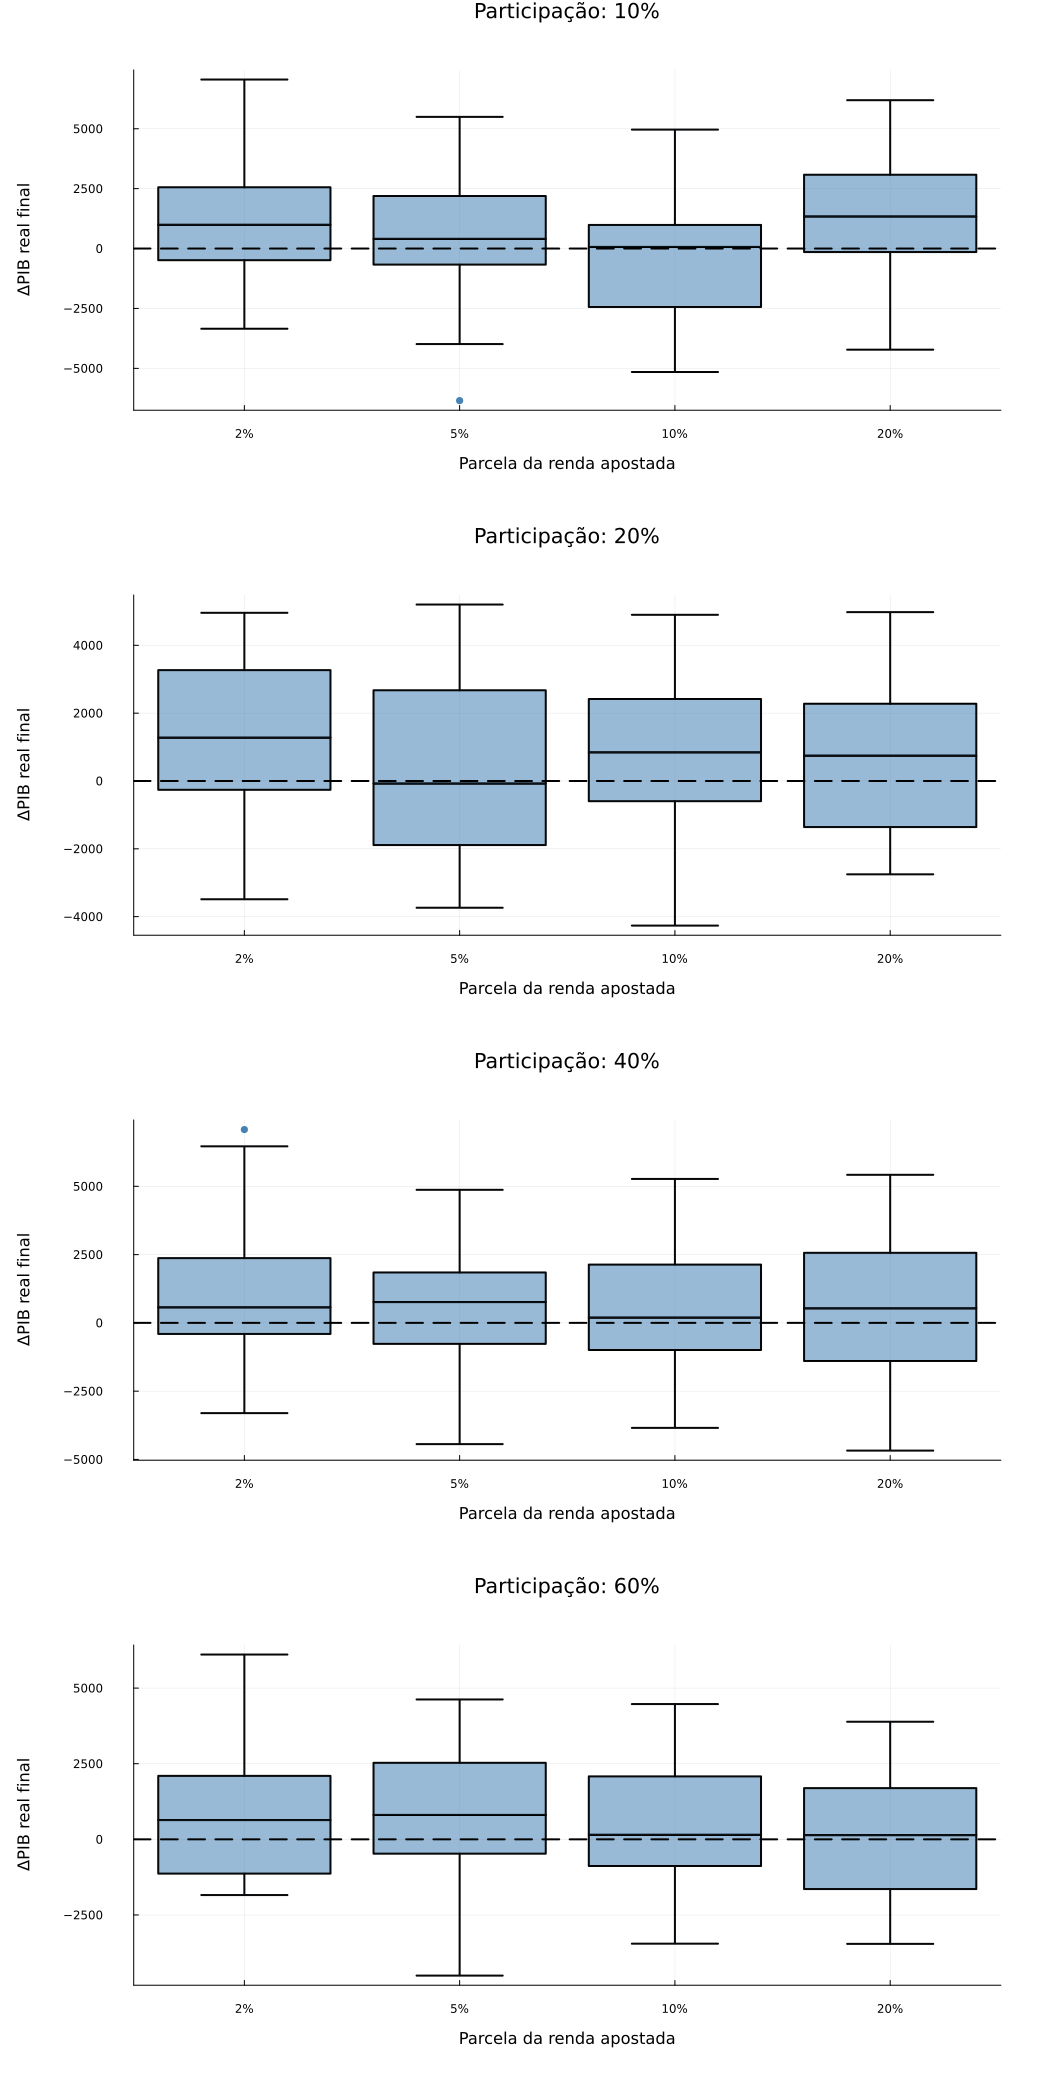

In [3]:
gambling_shares = sort(unique(grid_results.gambling_income_share[grid_results.gambling_income_share .> 0]))
participation_shares = sort(unique(grid_results.worker_participation_share))
share_position = Dict(share => index for (index, share) in enumerate(gambling_shares))
share_labels = ["$(round(Int, 100 * share))%" for share in gambling_shares]
final_effects = paired[paired.period .== maximum(paired.period), :]

p_gdp_boxes = map(participation_shares) do participation
    cell = final_effects[final_effects.worker_participation_share .== participation, :]
    x = [share_position[share] for share in cell.gambling_income_share]
    p = boxplot(
        x, cell.delta_real_gdp;
        xticks = (eachindex(gambling_shares), share_labels),
        xlabel = "Parcela da renda apostada",
        ylabel = "ΔPIB real final",
        title = "Participação: $(round(Int, 100 * participation))%",
        color = :steelblue, fillalpha = 0.55,
        outliers = true, legend = false,
    )
    hline!(p, [0.0]; color = :black, linestyle = :dash, label = false)
    p
end

plot(
    p_gdp_boxes...;
    layout = (length(participation_shares), 1), link = :y,
    size = (1050, 2100),
    left_margin = 18 * Plots.mm, bottom_margin = 12 * Plots.mm,
)

### Efeito sobre o PIB final e intervalo de confiança

Cada célula apresenta `efeito médio [limite inferior; limite superior]` do IC95%. As linhas representam a participação dos trabalhadores e as colunas representam a parcela da renda apostada.

In [4]:
final_gdp_summary = filter(:metric => ==("final_real_gdp"), grid_summary)
final_gdp_table = DataFrame(Participação = ["$(round(Int, 100 * participation))%" for participation in participation_shares])

for gambling_share in gambling_shares
    column = Symbol("$(round(Int, 100 * gambling_share))%")
    final_gdp_table[!, column] = [
        let row = only(eachrow(final_gdp_summary[(final_gdp_summary.gambling_income_share .== gambling_share) .& (final_gdp_summary.worker_participation_share .== participation), :]))
            @sprintf("%+.1f [%+.1f; %+.1f]", row.mean_delta, row.ci_lower, row.ci_upper)
        end
        for participation in participation_shares
    ]
end

display(final_gdp_table)

Row,Participação,2%,5%,10%,20%
,String,String,String,String,String
1,10%,+1283.8 [-27.1; +2594.6],+538.6 [-759.4; +1836.6],-408.2 [-1652.2; +835.9],+1175.9 [-83.4; +2435.1]
2,20%,+1120.2 [-135.0; +2375.5],+335.2 [-1023.8; +1694.2],+852.2 [-247.9; +1952.3],+616.2 [-472.1; +1704.5]
3,40%,+1089.6 [-230.2; +2409.3],+442.5 [-554.7; +1439.7],+637.6 [-497.3; +1772.5],+443.3 [-950.2; +1836.9]
4,60%,+812.0 [-167.6; +1791.5],+583.1 [-650.5; +1816.7],+667.5 [-407.2; +1742.2],+78.8 [-922.6; +1080.2]


## 4. Visão conjunta da grade

Os mapas mostram o efeito médio sobre PIB, Gini e o negativo das importações. No terceiro mapa, valores positivos significam que as importações caíram em relação à base.

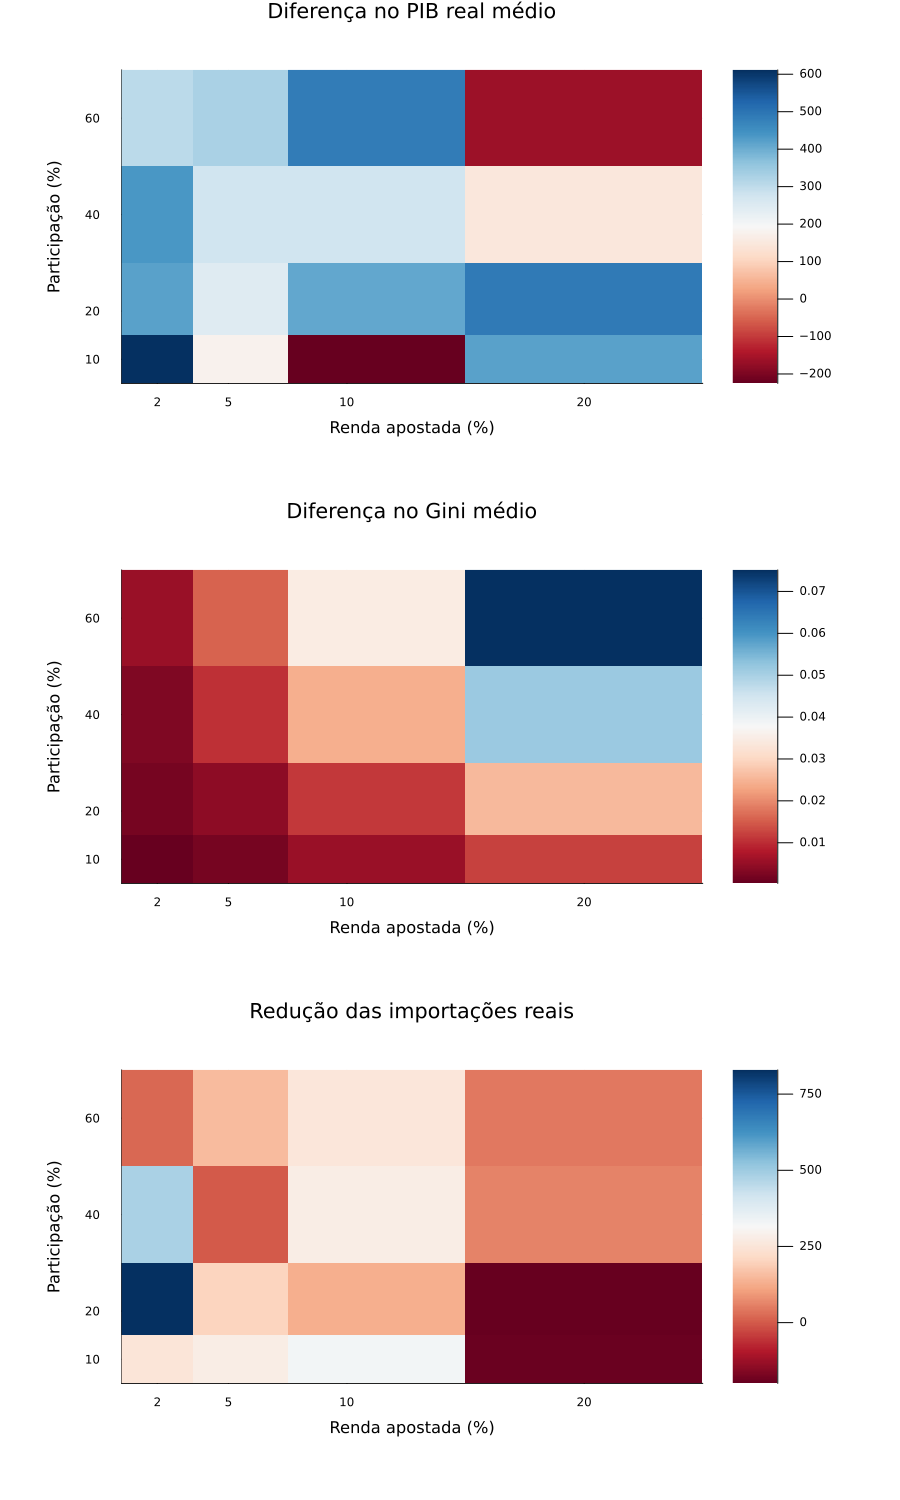

In [5]:
function delta_matrix(metric; sign = 1.0)
    table = filter(:metric => ==(metric), grid_summary)
    return [
        sign * only(table[(table.worker_participation_share .== participation) .& (table.gambling_income_share .== gambling), :mean_delta])
        for participation in participation_shares, gambling in gambling_shares
    ]
end

heatmap_options = (
    xlabel = "Renda apostada (%)", ylabel = "Participação (%)",
    xticks = (100 .* gambling_shares, string.(round.(Int, 100 .* gambling_shares))),
    yticks = (100 .* participation_shares, string.(round.(Int, 100 .* participation_shares))),
    color = :RdBu, size = (700, 520),
)
p_heat_gdp = heatmap(100 .* gambling_shares, 100 .* participation_shares, delta_matrix("mean_real_gdp"); heatmap_options..., title = "Diferença no PIB real médio")
p_heat_gini = heatmap(100 .* gambling_shares, 100 .* participation_shares, delta_matrix("mean_household_income_gini"); heatmap_options..., title = "Diferença no Gini médio")
p_heat_imports = heatmap(100 .* gambling_shares, 100 .* participation_shares, delta_matrix("mean_real_imports"; sign = -1.0); heatmap_options..., title = "Redução das importações reais")
plot(p_heat_gdp, p_heat_gini, p_heat_imports; layout = (3, 1), size = (900, 1500), left_margin = 18 * Plots.mm, bottom_margin = 14 * Plots.mm)

## 5. Resposta das empresas

Os quatro painéis verificam se a redistribuição aparece nas vendas e se se propaga para produção, emprego e investimento.

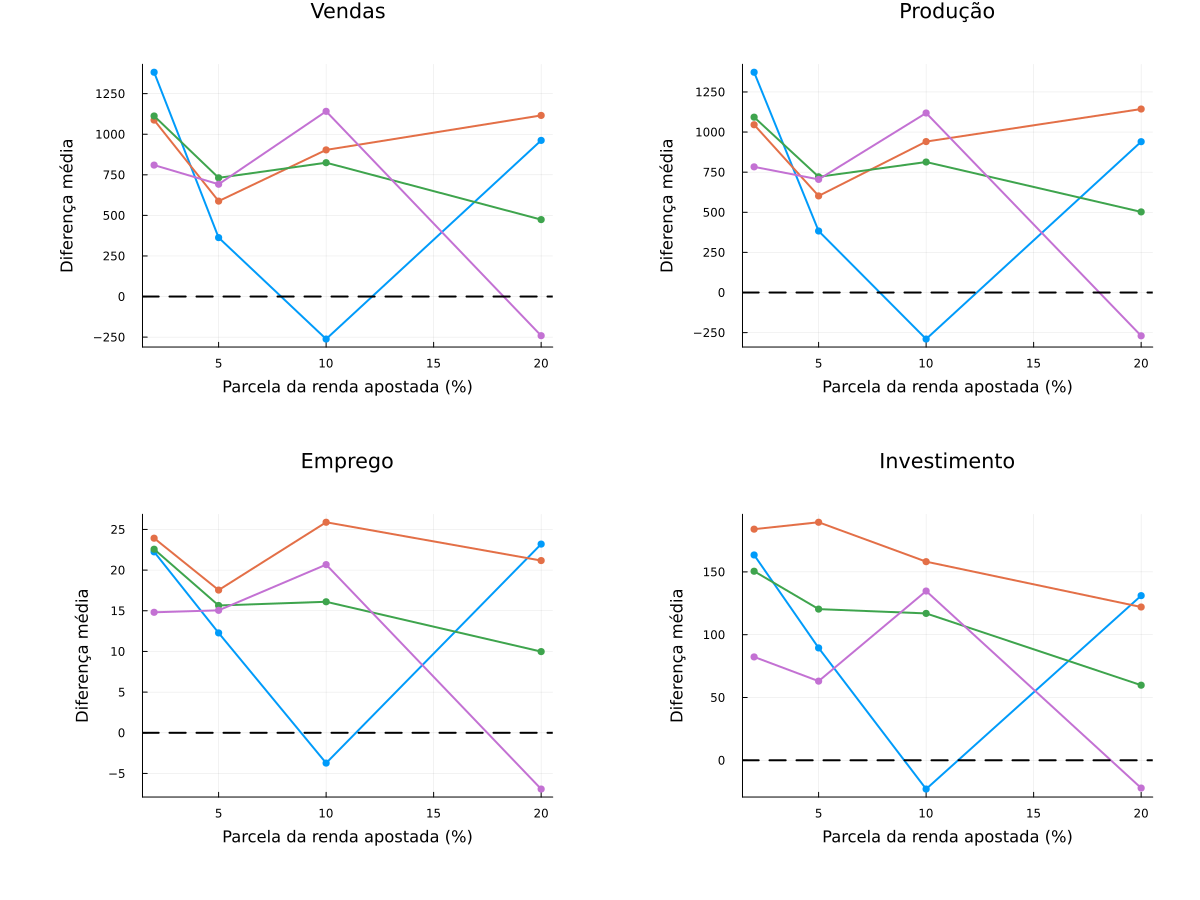

In [6]:
function interaction_plot(metric, title, ylabel)
    table = filter(:metric => ==(metric), grid_summary)
    p = plot(
        xlabel = "Parcela da renda apostada (%)", ylabel = ylabel,
        title = title, legend = false,
    )
    for participation in participation_shares
        cell = sort(table[table.worker_participation_share .== participation, :], :gambling_income_share)
        plot!(p, 100 .* cell.gambling_income_share, cell.mean_delta; marker = :circle, label = "$(round(Int, 100 * participation))%")
    end
    hline!(p, [0.0]; color = :black, linestyle = :dash, label = false)
    return p
end

p_sales = interaction_plot("mean_firm_sales", "Vendas", "Diferença média")
p_output = interaction_plot("mean_firm_output", "Produção", "Diferença média")
p_employment = interaction_plot("mean_firm_employment", "Emprego", "Diferença média")
p_investment = interaction_plot("mean_firm_investment", "Investimento", "Diferença média")
plot(p_sales, p_output, p_employment, p_investment; layout = (2, 2), size = (1200, 900), left_margin = 18 * Plots.mm, bottom_margin = 14 * Plots.mm)

## 6. Caminhos ao longo do tempo

Comparamos a base, o caso atual de 2% × 10% e o tratamento máximo de 20% × 60%. O primeiro gráfico mostra níveis médios; o segundo mostra diferenças pareadas.

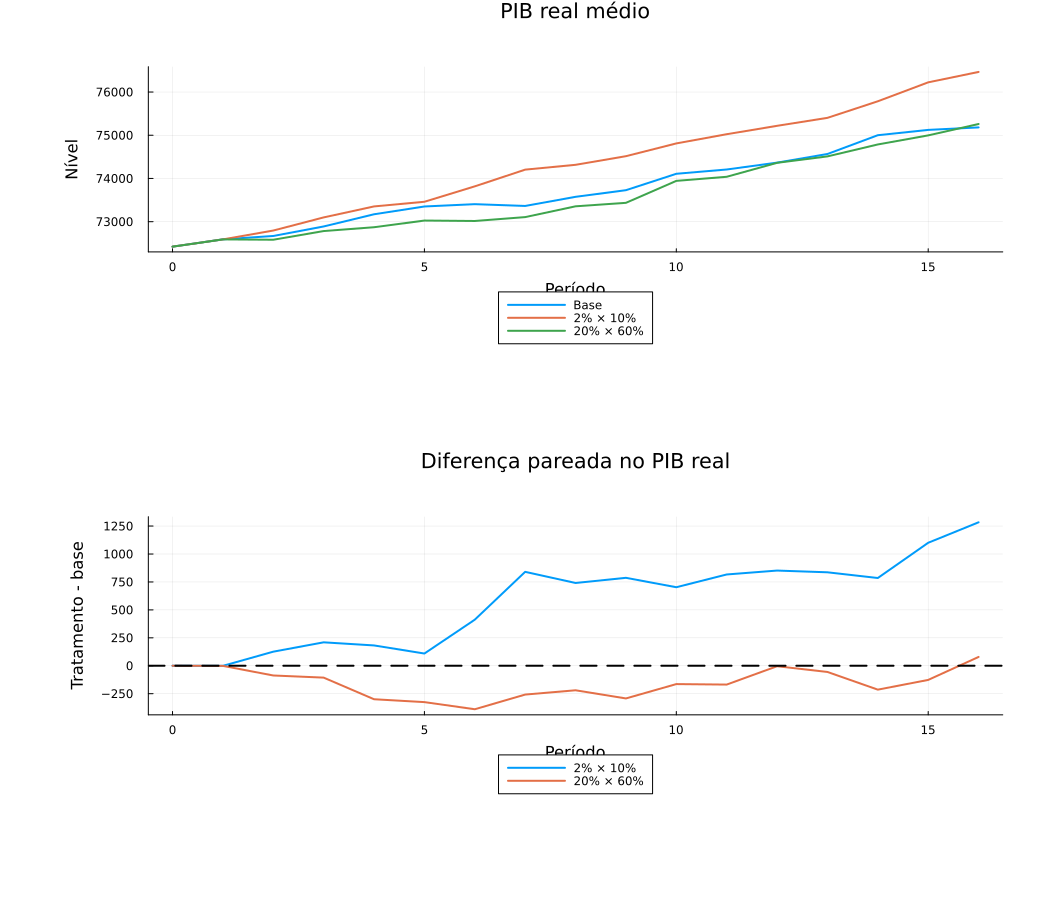

In [7]:
function mean_level_path(scenario_id)
    rows = grid_trace[grid_trace.scenario_id .== scenario_id, :]
    return combine(groupby(rows, :period), :real_gdp => mean => :real_gdp)
end
function mean_delta_path(scenario_id)
    rows = paired[paired.scenario_id .== scenario_id, :]
    return combine(groupby(rows, :period), :delta_real_gdp => mean => :delta_real_gdp)
end

base_path = mean_level_path("baseline")
current_path = mean_level_path("g2_p10")
maximum_path = mean_level_path("g20_p60")
p_levels = plot(base_path.period, base_path.real_gdp; label = "Base", title = "PIB real médio", xlabel = "Período", ylabel = "Nível", legend = :outerbottom)
plot!(p_levels, current_path.period, current_path.real_gdp; label = "2% × 10%")
plot!(p_levels, maximum_path.period, maximum_path.real_gdp; label = "20% × 60%")

current_delta = mean_delta_path("g2_p10")
maximum_delta = mean_delta_path("g20_p60")
p_deltas = plot(current_delta.period, current_delta.delta_real_gdp; label = "2% × 10%", title = "Diferença pareada no PIB real", xlabel = "Período", ylabel = "Tratamento - base", legend = :outerbottom)
plot!(p_deltas, maximum_delta.period, maximum_delta.delta_real_gdp; label = "20% × 60%")
hline!(p_deltas, [0.0]; color = :black, linestyle = :dash, label = false)
plot(p_levels, p_deltas; layout = (2, 1), size = (1050, 900), left_margin = 18 * Plots.mm, bottom_margin = 14 * Plots.mm)

## 7. Compras nacionais, importadas e exposição realizada

A origem das compras ajuda a verificar se a queda das importações coincide com uma mudança na composição das transações das famílias. A intensidade realizada corrige o parâmetro nominal pela renda efetivamente recebida pelos participantes.

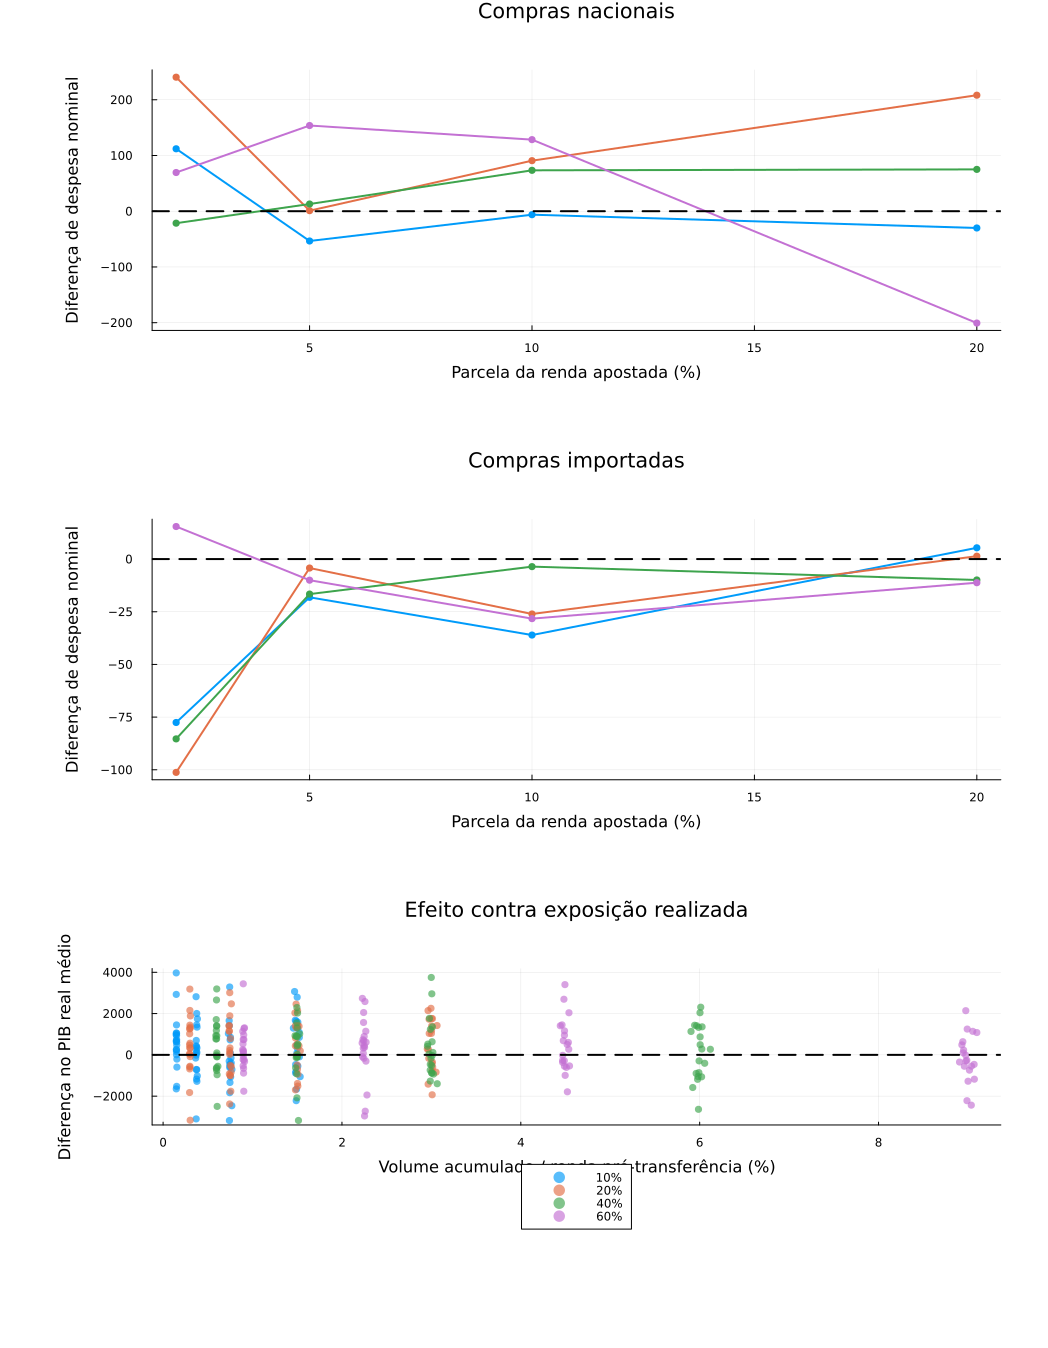

In [8]:
p_domestic = interaction_plot("mean_domestic_purchase_expenditure", "Compras nacionais", "Diferença de despesa nominal")
p_imported = interaction_plot("mean_imported_purchase_expenditure", "Compras importadas", "Diferença de despesa nominal")
participation_labels = ["$(round(Int, 100 * value))%" for value in run_effects.worker_participation_share]
p_intensity = scatter(
    100 .* run_effects.realized_transfer_intensity,
    run_effects.mean_delta_real_gdp;
    group = participation_labels, alpha = 0.65,
    xlabel = "Volume acumulado / renda pré-transferência (%)",
    ylabel = "Diferença no PIB real médio",
    title = "Efeito contra exposição realizada", legend = :outerbottom,
)
hline!(p_intensity, [0.0]; color = :black, linestyle = :dash, label = false)
plot(p_domestic, p_imported, p_intensity; layout = (3, 1), size = (1050, 1350), left_margin = 20 * Plots.mm, bottom_margin = 15 * Plots.mm)

## 8. Tabela completa das células

A tabela abaixo apresenta todas as combinações, evitando escolher apenas os resultados favoráveis.

In [9]:
gdp_cells = sort(filter(:metric => ==("mean_real_gdp"), grid_summary), [:worker_participation_share, :gambling_income_share])
gini_cells = sort(filter(:metric => ==("mean_household_income_gini"), grid_summary), [:worker_participation_share, :gambling_income_share])
import_cells = sort(filter(:metric => ==("mean_real_imports"), grid_summary), [:worker_participation_share, :gambling_income_share])
cell_table = DataFrame(
    renda_apostada_pct = 100 .* gdp_cells.gambling_income_share,
    participacao_pct = 100 .* gdp_cells.worker_participation_share,
    delta_PIB_medio = gdp_cells.mean_delta,
    IC95_PIB_inferior = gdp_cells.ci_lower,
    IC95_PIB_superior = gdp_cells.ci_upper,
    delta_Gini_medio = gini_cells.mean_delta,
    delta_importacoes_reais = import_cells.mean_delta,
    proporcao_runs_PIB_positivo = gdp_cells.positive_share,
)
display(cell_table)

Row,renda_apostada_pct,participacao_pct,delta_PIB_medio,IC95_PIB_inferior,IC95_PIB_superior,delta_Gini_medio,delta_importacoes_reais,proporcao_runs_PIB_positivo
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,2.0,10.0,611.426,17.0138,1205.84,0.000303464,-248.221,0.8
2,5.0,10.0,174.003,-452.713,800.718,0.00165637,-278.363,0.6
3,10.0,10.0,-224.981,-914.554,464.591,0.00543581,-328.583,0.35
4,20.0,10.0,422.048,-240.559,1084.66,0.0121554,193.372,0.6
5,2.0,20.0,421.886,-241.331,1085.1,0.00180078,-829.468,0.7
6,5.0,20.0,248.225,-412.579,909.029,0.00417945,-201.842,0.6
7,10.0,20.0,411.449,-168.927,991.825,0.0112847,-126.355,0.65
8,20.0,20.0,490.119,-92.4495,1072.69,0.0254785,199.376,0.6
9,2.0,40.0,438.807,-182.098,1059.71,0.00261059,-481.822,0.55


## 9. Síntese automática e limitações

In [10]:
best_cell = gdp_cells[argmax(gdp_cells.mean_delta), :]
worst_cell = gdp_cells[argmin(gdp_cells.mean_delta), :]
current_cell = only(eachrow(gdp_cells[(gdp_cells.gambling_income_share .== 0.02) .& (gdp_cells.worker_participation_share .== 0.10), :]))
maximum_cell = only(eachrow(gdp_cells[(gdp_cells.gambling_income_share .== 0.20) .& (gdp_cells.worker_participation_share .== 0.60), :]))
significant_positive = count((gdp_cells.ci_lower .> 0))
significant_negative = count((gdp_cells.ci_upper .< 0))
intensity_correlation = cor(run_effects.realized_transfer_intensity, run_effects.mean_delta_real_gdp)

display(MIME"text/markdown"(), Markdown.parse("""
### Leitura da grade

- No caso atual de **2% × 10%**, a diferença no PIB real médio foi **$(@sprintf("%+.1f", current_cell.mean_delta))**, com IC95% de **[$(@sprintf("%.1f", current_cell.ci_lower)), $(@sprintf("%.1f", current_cell.ci_upper))]**.
- No tratamento máximo de **20% × 60%**, a diferença foi **$(@sprintf("%+.1f", maximum_cell.mean_delta))**, com IC95% de **[$(@sprintf("%.1f", maximum_cell.ci_lower)), $(@sprintf("%.1f", maximum_cell.ci_upper))]**.
- A maior estimativa média apareceu em **$(round(Int, 100 * best_cell.gambling_income_share))% × $(round(Int, 100 * best_cell.worker_participation_share))%**: **$(@sprintf("%+.1f", best_cell.mean_delta))**.
- A menor estimativa média apareceu em **$(round(Int, 100 * worst_cell.gambling_income_share))% × $(round(Int, 100 * worst_cell.worker_participation_share))%**: **$(@sprintf("%+.1f", worst_cell.mean_delta))**.
- Entre as 16 células, **$significant_positive** têm IC95% inteiramente acima de zero e **$significant_negative** inteiramente abaixo de zero.
- A correlação descritiva entre exposição realizada e diferença no PIB médio é **$(@sprintf("%.3f", intensity_correlation))**.

Os resultados são exploratórios. A grade mede o efeito do mecanismo estilizado de transferência, não de um setor produtivo de apostas. Intervalos amplos indicam heterogeneidade entre sementes. As associações entre compras, empresas, importações e PIB ajudam a avaliar o canal, mas não constituem identificação causal adicional além do desenho pareado.
"""))

### Leitura da grade

  * No caso atual de **2% × 10%**, a diferença no PIB real médio foi **+611.4**, com IC95% de **[17.0, 1205.8]**.
  * No tratamento máximo de **20% × 60%**, a diferença foi **-164.7**, com IC95% de **[-694.0, 364.7]**.
  * A maior estimativa média apareceu em **2% × 10%**: **+611.4**.
  * A menor estimativa média apareceu em **10% × 10%**: **-225.0**.
  * Entre as 16 células, **1** têm IC95% inteiramente acima de zero e **0** inteiramente abaixo de zero.
  * A correlação descritiva entre exposição realizada e diferença no PIB médio é **-0.069**.

Os resultados são exploratórios. A grade mede o efeito do mecanismo estilizado de transferência, não de um setor produtivo de apostas. Intervalos amplos indicam heterogeneidade entre sementes. As associações entre compras, empresas, importações e PIB ajudam a avaliar o canal, mas não constituem identificação causal adicional além do desenho pareado.
